In [ ]:
#----------Task3:Price range Distribution----------#

In [1]:
# Import libraries

import matplotlib.pyplot as plt
import pandas as pd

In [2]:
# Load Dataset
df = pd.read_csv("Dataset .csv")

In [3]:
# Data Cleaning

initial_rows = len(df)

# Remove exact duplicate entries
df_clean = df.drop_duplicates()
duplicates_dropped = initial_rows - len(df_clean)

# Drop rows with missing values in the target column ('Price range')
df_clean = df_clean.dropna(subset=["Price range"])

# Ensure data type is strictly integer (1, 2, 3, or 4)
df_clean["Price range"] = df_clean["Price range"].astype(int)

# Verify there are no corrupted/out-of-bounds values (e.g., negative or >4)
df_clean = df_clean[df_clean["Price range"].between(1, 4)]

cleaned_rows = len(df_clean)
print(f"Initial Rows Loaded          : {initial_rows}")
print(f"Duplicate Rows Removed       : {duplicates_dropped}")
print(
    f"Corrupted/Missing Rows Dropped: {initial_rows - duplicates_dropped - cleaned_rows}"
)
print(f"Final Valid Rows for Analysis: {cleaned_rows}\n")

Initial Rows Loaded          : 9551
Duplicate Rows Removed       : 0
Corrupted/Missing Rows Dropped: 0
Final Valid Rows for Analysis: 9551



In [4]:
# Numerical Breakdown
price_counts = df_clean["Price range"].value_counts().sort_index()

print("Price Range Distribution (Counts):")
for tier, count in price_counts.items():
    print(f"Price Range {tier}: {count} restaurants")

Price Range Distribution (Counts):
Price Range 1: 4444 restaurants
Price Range 2: 3113 restaurants
Price Range 3: 1408 restaurants
Price Range 4: 586 restaurants


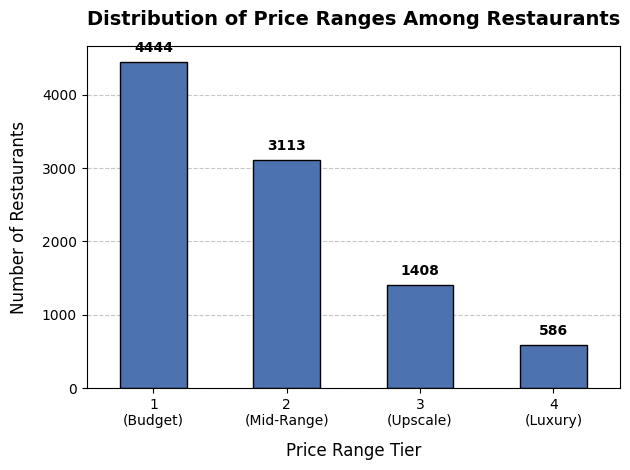

In [5]:
# Visualization(Bar chart and Histogram)

ax = price_counts.plot(kind="bar", color="#4C72B0", edgecolor="black", zorder=2)

plt.title(
    "Distribution of Price Ranges Among Restaurants",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Price Range Tier", fontsize=12, labelpad=10)
plt.ylabel("Number of Restaurants", fontsize=12, labelpad=10)

# Custom descriptive x-axis labels
plt.xticks(
    ticks=[0, 1, 2, 3],
    labels=["1\n(Budget)", "2\n(Mid-Range)", "3\n(Upscale)", "4\n(Luxury)"],
    rotation=0,
    fontsize=10,
)

plt.grid(axis="y", linestyle="--", alpha=0.7, zorder=1)

# Annotate each bar with its exact count for professional readability
for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height()):}",
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha="center",
        va="bottom",
        xytext=(0, 5),
        textcoords="offset points",
        fontsize=10,
        fontweight="bold",
    )

# Prevent label clipping and save as a publication-ready image
plt.tight_layout()
plt.savefig("price_range_distribution.png", dpi=300)

In [6]:
# The Percentage of restaurants in each price range category 
price_percentages = (df_clean["Price range"].value_counts(normalize=True) * 100).sort_index()

for tier, pct in price_percentages.items():
    print(f"Price Range {tier}: {pct:.2f}%")

Price Range 1: 46.53%
Price Range 2: 32.59%
Price Range 3: 14.74%
Price Range 4: 6.14%
